In [1]:
import os
print (os.getenv("COINGECKO_API_KEY"))

CG-6bJ3mSAgrpEho2mjo1mVuS2o


In [3]:
import os
from pathlib import Path

# Set root folder
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

os.chdir(project_root)
print("CWD =", Path.cwd())


CWD = c:\Users\stada\OneDrive\Desktop\Capstone\src\Agentic-Crypto-Return-Service


# Raw Data

We get data from two sources, YahooFinance and CoinGeko. we were planning to get data mainly from CoinGeko and just use YahooFinance for Cross checking and validation, but unfortunately CoinGeko sells its api and the developer api key only returns data for 365 days. So, we had to switch to YahooFinance as the primary source.

### Raw Data .... OHLCV

In [ ]:
from core.pipelines.daily_ohlcv_pipeline import run_one_ticker , run_all

# To run the pipeline for a single ticker we can use the `run_one_ticker` function. useful for test and debug
# run_one_ticker("BTC-USD")


# To run the pipeline for all tickers we can use the `run_all` function. This will run the pipeline for all tickers in the Coins.json.
run_all()


saved: data\raw\ohlcv\BTC-USD_daily.csv
saved: data\raw\ohlcv\ETH-USD_daily.csv
saved: data\raw\ohlcv\BNB-USD_daily.csv
saved: data\raw\ohlcv\XRP-USD_daily.csv
saved: data\raw\ohlcv\SOL-USD_daily.csv
saved: data\raw\ohlcv\DOGE-USD_daily.csv
saved: data\raw\ohlcv\ADA-USD_daily.csv
saved: data\raw\ohlcv\LINK-USD_daily.csv
saved: data\raw\ohlcv\AVAX-USD_daily.csv
saved: data\raw\ohlcv\FLOKI-USD_daily.csv


In [7]:
import pandas as pd

df = pd.read_csv("data/raw/ohlcv/BTC-USD_daily.csv")


df.head(10)

,date,open,high,low,close,volume,ticker
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,BTC-USD
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,BTC-USD
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,BTC-USD
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,BTC-USD
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,BTC-USD
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,24127600,BTC-USD
6,2014-09-23,402.092010,441.557007,396.196991,435.790985,45099500,BTC-USD
7,2014-09-24,435.751007,436.112000,421.131989,423.204987,30627700,BTC-USD
8,2014-09-25,423.156006,423.519989,409.467987,411.574005,26814400,BTC-USD
9,2014-09-26,411.428986,414.937988,400.009003,404.424988,21460800,BTC-USD


### Raw Data .... Marketcap


In [6]:
from core.pipelines.marketcap_pipeline import run_one_symbol , run_all

# To run the pipeline for a single ticker we can use the `run_one_ticker` function. useful for test and debug
# run_one_symbol("bitcoin")


# To run the pipeline for all tickers we can use the `run_all` function. This will run the pipeline for all tickers in the Coins.json.
run_all()

[BTC] added 3 new rows (days_requested=4)
saved: data\raw\market_cap\BTC_daily.csv
[ETH] added 3 new rows (days_requested=4)
saved: data\raw\market_cap\ETH_daily.csv
[BNB] added 0 new rows (days_requested=4)
saved: data\raw\market_cap\BNB_daily.csv
[XRP] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\XRP_daily.csv
[SOL] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\SOL_daily.csv
[DOGE] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\DOGE_daily.csv
[ADA] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\ADA_daily.csv
[LINK] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\LINK_daily.csv
[AVAX] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\AVAX_daily.csv
[FLOKI] added 0 new rows (days_requested=365)
saved: data\raw\market_cap\FLOKI_daily.csv


In [7]:
df = pd.read_csv("data/raw/market_cap/BTC_daily.csv")


df.head(10)

,date,market_cap,coingecko_id,symbol
0,2025-02-09,1.914212e+12,bitcoin,BTC
1,2025-02-10,1.913069e+12,bitcoin,BTC
2,2025-02-11,1.930743e+12,bitcoin,BTC
3,2025-02-12,1.898789e+12,bitcoin,BTC
4,2025-02-13,1.936842e+12,bitcoin,BTC
5,2025-02-14,1.914315e+12,bitcoin,BTC
6,2025-02-15,1.931657e+12,bitcoin,BTC
7,2025-02-16,1.934308e+12,bitcoin,BTC
8,2025-02-17,1.905012e+12,bitcoin,BTC
9,2025-02-18,1.898998e+12,bitcoin,BTC


# Processed Data


In [8]:
from core.pipelines.build_processed_daily import build_all , build_one
# build_one("BTC","BTC-USD")


build_all()

built: data\processed\daily\BTC_daily.csv
built: data\processed\daily\ETH_daily.csv
built: data\processed\daily\BNB_daily.csv
built: data\processed\daily\XRP_daily.csv
built: data\processed\daily\SOL_daily.csv
built: data\processed\daily\DOGE_daily.csv
built: data\processed\daily\ADA_daily.csv
built: data\processed\daily\LINK_daily.csv
built: data\processed\daily\AVAX_daily.csv
built: data\processed\daily\FLOKI_daily.csv


In [14]:
df = pd.read_csv("data/processed/daily/BTC_daily.csv")
print (f"first 5 rows of df: \n{df.head(5)}")
print ("="*50 , "\n")
print (f"last 5 rows of df: \n{df.tail(5)}")
print ("="*50 , "\n")

print (f"Null values in df: \n{df.isnull().sum()}")

first 5 rows of df: 
         date        open        high         low       close    volume  \
0  2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800   
1  2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200   
2  2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700   
3  2014-09-20  394.673004  423.295990  389.882996  408.903992  36863600   
4  2014-09-21  408.084991  412.425995  393.181000  398.821014  26580100   

    ticker  market_cap  
0  BTC-USD         NaN  
1  BTC-USD         NaN  
2  BTC-USD         NaN  
3  BTC-USD         NaN  
4  BTC-USD         NaN  

last 5 rows of df: 
            date          open          high           low         close  \
4160  2026-02-06  62704.453125  71681.304688  60074.203125  70555.390625   
4161  2026-02-07  70553.796875  71611.148438  67364.445312  69281.968750   
4162  2026-02-09  70306.117188  70668.898438  70205.554688  70205.554688   
4163  2026-02-10  70137.390625  70464.265625  67913.0

# Feature Engineering


In [8]:
from core.pipelines.features_pipeline import run_all


run_all()

saved: data\processed\features\BTC_features.csv
saved: data\processed\features\ETH_features.csv
saved: data\processed\features\BNB_features.csv
saved: data\processed\features\XRP_features.csv
saved: data\processed\features\SOL_features.csv
saved: data\processed\features\DOGE_features.csv
saved: data\processed\features\ADA_features.csv
saved: data\processed\features\LINK_features.csv
saved: data\processed\features\AVAX_features.csv
saved: data\processed\features\FLOKI_features.csv


c:\Users\stada\OneDrive\Desktop\Capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\stada\OneDrive\Desktop\Capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\stada\OneDrive\Desktop\Capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
df = pd.read_csv("data/processed/features/BTC_features.csv")


df.head(10)

,date,open,high,low,close,volume,ticker,market_cap,log_ret_1d,log_ret_5d,log_ret_10d,vol_7d,vol_30d,risk_adj_ret_1d,vol_ratio_7d_30d,drawdown_30d
0,2014-10-17,382.756012,385.477997,375.389008,383.757996,13600700,BTC-USD,NaN,0.003137,0.013667,0.132345,0.026790,0.039426,0.079569,0.679485,-0.119399
1,2014-10-18,383.976013,395.157990,378.971008,391.441986,11416800,BTC-USD,NaN,0.019825,0.002630,0.103539,0.026916,0.037466,0.529154,0.718425,-0.101767
2,2014-10-19,391.253998,393.938995,386.457001,389.545990,5914570,BTC-USD,NaN,-0.004855,-0.028655,0.065013,0.023034,0.035087,-0.138383,0.656492,-0.106117
3,2014-10-20,389.230988,390.084015,378.252014,382.845001,16419000,BTC-USD,NaN,-0.017352,-0.030681,0.057197,0.020794,0.034557,-0.502125,0.601745,-0.121494
4,2014-10-21,382.420990,392.645996,380.834015,386.475006,14188900,BTC-USD,NaN,0.009437,0.010192,0.064597,0.017553,0.034345,0.274770,0.511079,-0.113164
5,2014-10-22,386.118011,388.575989,382.248993,383.157990,11641300,BTC-USD,NaN,-0.008620,-0.001565,0.012102,0.017087,0.034325,-0.251123,0.497788,-0.120776
6,2014-10-23,382.962006,385.048004,356.446991,358.416992,26456900,BTC-USD,NaN,-0.066750,-0.088140,-0.085511,0.028106,0.032682,-2.042438,0.859986,-0.153089
7,2014-10-24,358.591003,364.345001,353.304993,358.345001,15585700,BTC-USD,NaN,-0.000201,-0.083486,-0.112141,0.027887,0.032413,-0.006198,0.860369,-0.129330
8,2014-10-25,358.610992,359.860992,342.877014,347.270996,18127500,BTC-USD,NaN,-0.031391,-0.097525,-0.128205,0.025433,0.032503,-0.965792,0.782496,-0.141322
9,2014-10-26,347.487000,359.221008,343.931000,354.704010,11272500,BTC-USD,NaN,0.021178,-0.085784,-0.075591,0.029154,0.032782,0.646023,0.889321,-0.115164


# Model 

### a) Simple rule-based model using `Monte carlo`

In [15]:
%run notebooks/demo_scenario_engine.py

Asset: BTC
Distribution: {'dist': 'normal', 'mu': 0.001199367417760348, 'sigma': 0.03543838238715027, 'n': 4164}
Summary: {'start_price': 67479.5546875, 'horizon_days': 30, 'n_scenarios': 90000, 'terminal_mean': 71188.57621949607, 'terminal_median': 69815.3760437214, 'terminal_p05': 50832.04604392506, 'terminal_p50': 69815.3760437214, 'terminal_p95': 96095.61329005277}
Terminal min / max: 32639.567256957067 159778.8869727989


### b) trained `GradientBoostingRegressor`

#### b1) load the Model

In [4]:
import joblib
from pathlib import Path

model_path = Path("artifacts/models/BTC_quantile_bundle.joblib")

bundle = joblib.load(model_path)

print("Loaded quantiles:", bundle.quantiles)
print("Feature columns:", bundle.feature_cols)


Loaded quantiles: [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
Feature columns: ['log_ret_1d', 'log_ret_5d', 'log_ret_10d', 'vol_7d', 'vol_30d', 'risk_adj_ret_1d', 'vol_ratio_7d_30d', 'drawdown_30d']


#### b2) load features

In [5]:

from core.models.probabilistic_quantile import load_features_csv

features_df = load_features_csv("data/processed/features/BTC_features.csv")

features_df.tail()


,date,open,high,low,close,volume,ticker,market_cap,log_ret_1d,log_ret_5d,log_ret_10d,vol_7d,vol_30d,risk_adj_ret_1d,vol_ratio_7d_30d,drawdown_30d
4130,2026-02-06,62704.453125,71681.304688,60074.203125,70555.390625,114674259489,BTC-USD,1.262033e+12,0.118003,-0.087075,-0.233390,0.082695,0.042624,2.768437,1.940077,-0.272095
4131,2026-02-07,70553.796875,71611.148438,67364.445312,69281.968750,62347107663,BTC-USD,1.410204e+12,-0.018213,-0.127316,-0.252523,0.080536,0.042647,-0.427078,1.888452,-0.285232
4132,2026-02-09,70306.117188,70668.898438,70205.554688,70205.554688,40095264768,BTC-USD,1.407782e+12,0.013243,-0.074472,-0.186053,0.081361,0.042838,0.309133,1.899257,-0.275704
4133,2026-02-10,70137.390625,70464.265625,67913.093750,68793.960938,40593063077,BTC-USD,1.372759e+12,-0.020311,-0.059613,-0.201231,0.079870,0.042870,-0.473794,1.863086,-0.290267
4134,2026-02-12,67025.554688,67527.382812,67025.554688,67479.554688,50343575552,BTC-USD,1.350833e+12,-0.019291,0.073430,-0.152816,0.079373,0.042825,-0.450465,1.853409,-0.303827


#### b3) Predict Next day quantiles

In [6]:
from core.models.probabilistic_quantile import predict_quantiles

x = features_df.iloc[[-1]]   

qpred = predict_quantiles(bundle, x)

qpred


,q_0.01,q_0.05,q_0.10,q_0.25,q_0.50,q_0.75,q_0.90,q_0.95,q_0.99
4134,-0.100918,-0.053539,-0.040209,-0.016633,0.002893,0.01361,0.041871,0.057837,0.09494


These numbers show the model’s prediction for tomorrow’s return, but not as a single number. Instead, it gives a range of possible outcomes with different probabilities. For example, the 5% quantile means there is about a 5% chance that tomorrow’s return could be worse than around -5%. The median value shows the most typical scenario, which here is a small positive return of about 0.3%. On the positive side, the 99% quantile means that in very optimistic cases, the return could be close to +9%. So basically, the model is not just saying “the return will be X,” it is describing the whole risk and return picture for tomorrow.


#### b2) VaR / CVaR

In [7]:
from core.models.probabilistic_quantile import sample_from_quantiles, var_cvar

samples = sample_from_quantiles(
    qpred,
    quantiles=bundle.quantiles,
    n_samples=5000,
    seed=42
)

VaR, CVaR = var_cvar(samples, alpha=0.05)

print("VaR_5:", VaR)
print("CVaR_5:", CVaR)


VaR_5: -0.053283114180604975
CVaR_5: -0.08006261214512245


VaR shows how much we could lose in the worst 5% of cases. In our result, a VaR of about -5% means there is a 5% chance that tomorrow’s return could be worse than roughly -5%. CVaR goes one step further. It tells us how bad the loss would be on average if we actually fall into that worst 5%. Here, the CVaR of about -8% means that in those very bad scenarios, the average loss would be around 8%. So basically, VaR shows the risk threshold, and CVaR shows how painful it gets beyond that threshold.

#### b3) Predict for Horizon

Summary:
{'median': 0.005949464915737508, 'mean': 0.006740146045404615, 'p05': -0.24921123737595435, 'p95': 0.26626679553193083, 'VaR_5': -0.24921123737595435, 'CVaR_5': -0.3107270349323028}


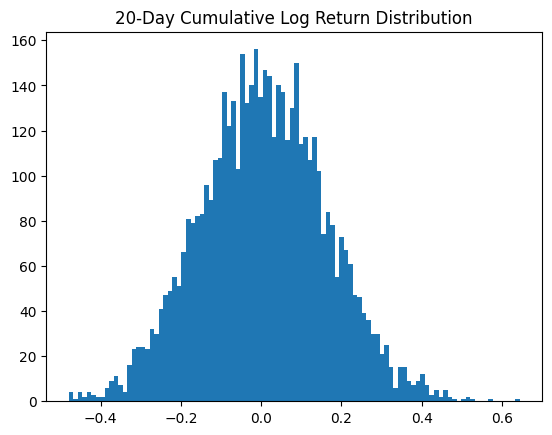

In [8]:
from core.models.horizon_scenarios import forecast_horizon

fc = forecast_horizon(
    bundle=bundle,
    features_df=features_df,
    start_date=str(x["date"].iloc[0].date()),
    horizon_days=20,
    n_scenarios=5000,
    alpha=0.05,
    seed=42
)

print("Summary:")
print(fc.summary)


import matplotlib.pyplot as plt

plt.hist(fc.samples, bins=100)
plt.title("20-Day Cumulative Log Return Distribution")
plt.show()



# Agent Decision Logic


In [ ]:

%run notebooks/run_allocation_on_csv_data.py


Loaded symbols: ['BTC', 'ETH', 'BNB', 'XRP', 'SOL', 'DOGE', 'ADA', 'LINK', 'AVAX', 'FLOKI']
Usable assets: ['BTC', 'ETH', 'BNB', 'XRP', 'SOL', 'DOGE', 'ADA', 'LINK', 'AVAX', 'FLOKI']

RiskTolerance = conservative
  ADA: 0.093939
  AVAX: 0.098036
  BNB: 0.115147
  BTC: 0.112838
  DOGE: 0.096632
  ETH: 0.099607
  FLOKI: 0.090338
  LINK: 0.101650
  SOL: 0.095518
  XRP: 0.096297
  SUM: 1.000000

RiskTolerance = moderate
  ADA: 0.096994
  AVAX: 0.099069
  BNB: 0.107127
  BTC: 0.105989
  DOGE: 0.098539
  ETH: 0.099803
  FLOKI: 0.095355
  LINK: 0.100961
  SOL: 0.097970
  XRP: 0.098193
  SUM: 1.000000

RiskTolerance = aggressive
  ADA: 0.098477
  AVAX: 0.099505
  BNB: 0.103523
  BTC: 0.102904
  DOGE: 0.099332
  ETH: 0.099847
  FLOKI: 0.097794
  LINK: 0.100500
  SOL: 0.099048
  XRP: 0.099069
  SUM: 1.000000
